# 📐 Calculus for Data Science & Generative AI
### A 2-Hour Practical Journey from Derivatives to Gradient Descent

---

**What you'll learn today:**

| Topic | Why it matters in DS / GenAI |
|---|---|
| Functions & Limits | Building intuition before the math |
| Derivatives | How every ML model "learns" |
| Partial Derivatives & Gradients | Multi-variable loss functions |
| Chain Rule | Backpropagation in neural networks |
| Gradient Descent | Training any model end-to-end |

> 💡 **Philosophy:** We won't just prove theorems. Every concept is immediately connected to something you'll use in a real model.

---


## ⚙️ Setup — Import Libraries

In [6]:
!pip install sympy

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)

   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   -------------------- ------------------- 1/2 [sympy]
   -------------------- ------------------- 1/2 [sympy]
   -------------------- -------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from mpl_toolkits.mplot3d import Axes3D

# Pretty printing for symbolic math
sp.init_printing(use_unicode=True)

# Consistent plot style
plt.rcParams.update({
    'figure.figsize': (9, 4),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12
})

print("✅ All libraries loaded!")


✅ All libraries loaded!


---
## 1️⃣ Functions — The Language of ML

A **function** maps an input to an output:

$$f: \mathbb{R}^n \rightarrow \mathbb{R}$$

In ML, the most important function is the **loss function** — it maps model parameters to a single number representing *how wrong the model is*. Our entire goal is to minimise it.

### Common functions in ML

| Function | Formula | Used for |
|---|---|---|
| Linear | $f(x) = wx + b$ | Linear regression |
| Sigmoid | $\sigma(x) = \dfrac{1}{1 + e^{-x}}$ | Binary classification, gates in LSTMs |
| ReLU | $f(x) = \max(0, x)$ | Hidden layers in deep nets |
| Softmax | $\sigma(z)_i = \dfrac{e^{z_i}}{\sum_j e^{z_j}}$ | Output layer, attention weights |


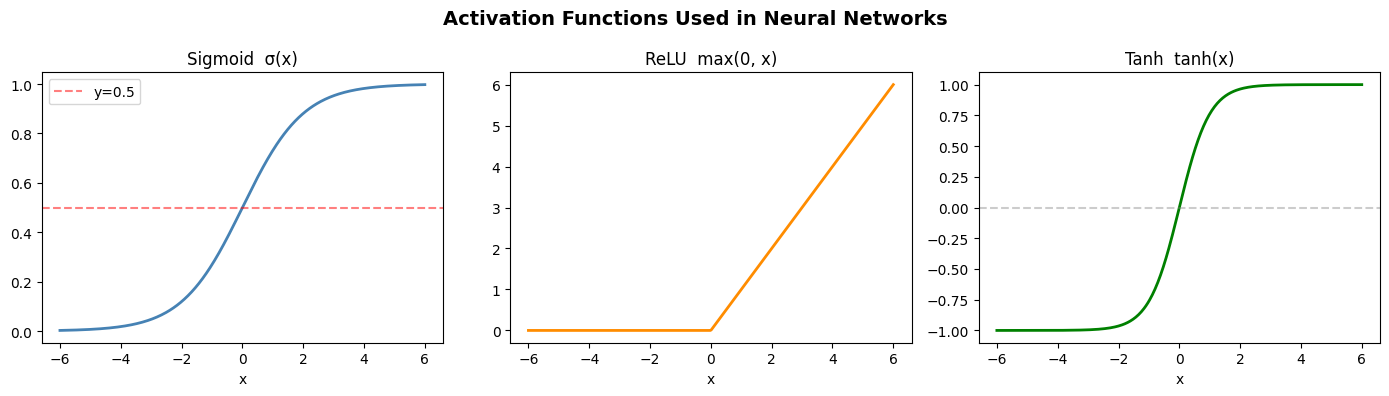

Notice: Sigmoid squashes output to (0,1) — perfect for probabilities.
ReLU is zero for negatives — this is why deep networks are sparse and efficient.


In [2]:
x = np.linspace(-6, 6, 400)

sigmoid = 1 / (1 + np.exp(-x))
relu    = np.maximum(0, x)
tanh    = np.tanh(x)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(x, sigmoid, color='steelblue', lw=2)
axes[0].set_title('Sigmoid  σ(x)')
axes[0].set_xlabel('x')
axes[0].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='y=0.5')
axes[0].legend()

axes[1].plot(x, relu, color='darkorange', lw=2)
axes[1].set_title('ReLU  max(0, x)')
axes[1].set_xlabel('x')

axes[2].plot(x, tanh, color='green', lw=2)
axes[2].set_title('Tanh  tanh(x)')
axes[2].set_xlabel('x')
axes[2].axhline(0, color='gray', linestyle='--', alpha=0.4)

plt.suptitle('Activation Functions Used in Neural Networks', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Notice: Sigmoid squashes output to (0,1) — perfect for probabilities.")
print("ReLU is zero for negatives — this is why deep networks are sparse and efficient.")


---
## 2️⃣ Limits — The Foundation of Derivatives

The **limit** asks: *what value does $f(x)$ approach as $x$ gets closer and closer to some point $a$?*

$$\lim_{x \to a} f(x) = L$$

### Why limits matter for us

The derivative is *defined* as a limit:

$$f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

This is the **secant line becoming a tangent line** — the instantaneous rate of change.

Let's watch it happen visually:


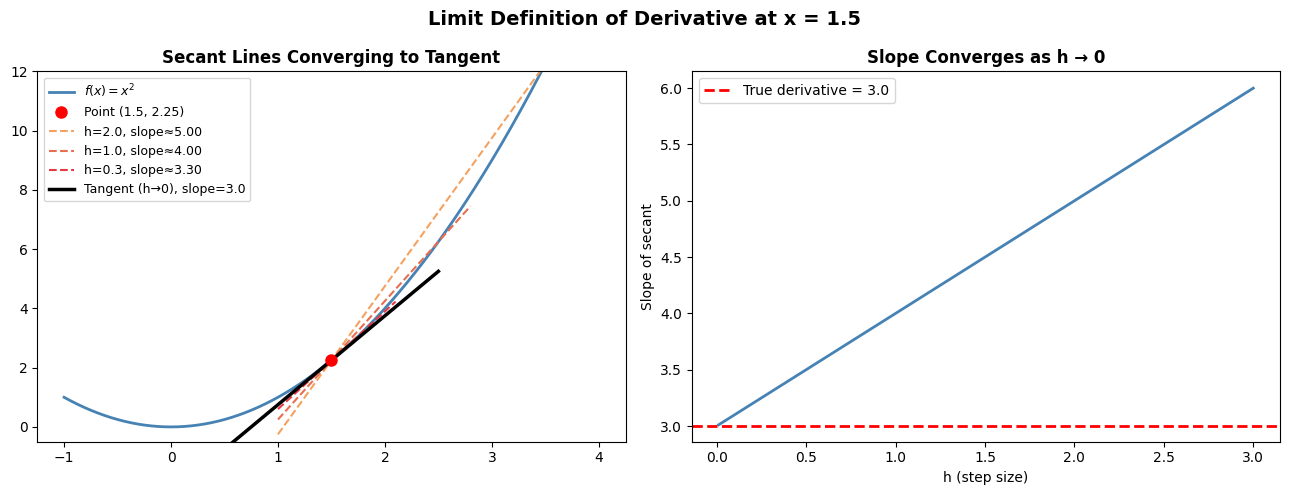

In [3]:
def f(x):
    return x**2

x0 = 1.5  # point of interest
x_range = np.linspace(-1, 4, 400)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: secant → tangent
ax = axes[0]
ax.plot(x_range, f(x_range), 'steelblue', lw=2, label='$f(x) = x^2$')
ax.plot(x0, f(x0), 'ro', markersize=8, zorder=5, label=f'Point ({x0}, {f(x0)})')

colors = ['#f4a261', '#e76f51', '#e63946']
for h, col in zip([2.0, 1.0, 0.3], colors):
    x1 = x0 + h
    slope = (f(x1) - f(x0)) / h
    xs = np.linspace(x0 - 0.5, x0 + h + 0.3, 100)
    ys = f(x0) + slope * (xs - x0)
    ax.plot(xs, ys, '--', color=col, lw=1.5, label=f'h={h}, slope≈{slope:.2f}')

# True tangent (derivative of x² at x0 = 2*x0)
true_slope = 2 * x0
xs_t = np.linspace(x0 - 1, x0 + 1, 100)
ys_t = f(x0) + true_slope * (xs_t - x0)
ax.plot(xs_t, ys_t, 'black', lw=2.5, label=f'Tangent (h→0), slope={true_slope}')
ax.set_title('Secant Lines Converging to Tangent', fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(-0.5, 12)

# Right: slope vs h
ax2 = axes[1]
h_vals = np.linspace(0.01, 3, 300)
slopes = [(f(x0 + h) - f(x0)) / h for h in h_vals]
ax2.plot(h_vals, slopes, 'steelblue', lw=2)
ax2.axhline(true_slope, color='red', linestyle='--', lw=2, label=f'True derivative = {true_slope}')
ax2.set_xlabel('h (step size)')
ax2.set_ylabel('Slope of secant')
ax2.set_title('Slope Converges as h → 0', fontweight='bold')
ax2.legend()

plt.suptitle(f'Limit Definition of Derivative at x = {x0}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 3️⃣ Derivatives — How Models Learn

The derivative $f'(x)$ gives the **instantaneous rate of change** of $f$ at $x$.  
Geometrically: the **slope of the tangent line**.

### Key Rules (you need these every day)

| Rule | Formula |
|---|---|
| Power Rule | $\dfrac{d}{dx}[x^n] = nx^{n-1}$ |
| Sum Rule | $\dfrac{d}{dx}[f+g] = f' + g'$ |
| Product Rule | $\dfrac{d}{dx}[fg] = f'g + fg'$ |
| Chain Rule | $\dfrac{d}{dx}[f(g(x))] = f'(g(x)) \cdot g'(x)$ |
| Exponential | $\dfrac{d}{dx}[e^x] = e^x$ |
| Natural Log | $\dfrac{d}{dx}[\ln x] = \dfrac{1}{x}$ |

### 🔑 DS Application: Derivative of Loss Function

In linear regression, our **MSE loss** is:

$$\mathcal{L}(w) = \frac{1}{n}\sum_{i=1}^{n}(y_i - wx_i)^2$$

The derivative tells us which direction to move $w$ to reduce loss:

$$\frac{\partial \mathcal{L}}{\partial w} = -\frac{2}{n}\sum_{i=1}^{n} x_i(y_i - wx_i)$$


In [8]:
# --- Symbolic derivatives with SymPy ---
x = sp.Symbol('x')

functions = {
    'x³':         x**3,
    'sin(x)':     sp.sin(x),
    'e^x':        sp.exp(x),
    'ln(x)':      sp.ln(x),
    'sigmoid':    1 / (1 + sp.exp(-x)),
    'x²·sin(x)':  x**2 * sp.sin(x),
}

print("=" * 52)
print(f"{'Function':<18} {'Derivative':<34}")
print("=" * 52)
for name, expr in functions.items():
    deriv = sp.diff(expr, x)
    print(f"  {name:<16} {str(sp.simplify(deriv)):<34}")
print("=" * 52)


Function           Derivative                        
  x³               3*x**2                            
  sin(x)           cos(x)                            
  e^x              exp(x)                            
  ln(x)            1/x                               
  sigmoid          1/(4*cosh(x/2)**2)                
  x²·sin(x)        x*(x*cos(x) + 2*sin(x))           


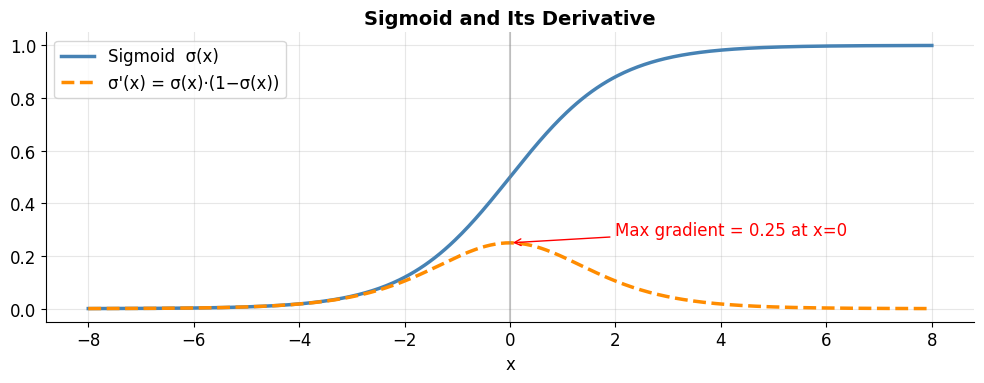

Key insight: The sigmoid gradient is highest at x=0 and nearly 0 at extremes.
This causes the 'vanishing gradient' problem in deep networks — ReLU fixes it!


In [10]:
# --- Visualise: sigmoid and its derivative ---
x_vals = np.linspace(-8, 8, 500)
sig     = 1 / (1 + np.exp(-x_vals))
d_sig   = sig * (1 - sig)        # σ(x)·(1−σ(x))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x_vals, sig,   color='steelblue', lw=2.5, label='Sigmoid  σ(x)')
ax.plot(x_vals, d_sig, color='darkorange', lw=2.5, linestyle='--',
        label="σ'(x) = σ(x)·(1−σ(x))")
ax.axvline(0, color='gray', alpha=0.4)
ax.set_title("Sigmoid and Its Derivative", fontsize=14, fontweight='bold')
ax.set_xlabel("x")
ax.legend()

# Annotate maximum gradient
peak_x = 0
peak_y = 0.25
ax.annotate('Max gradient = 0.25 at x=0',
            xy=(peak_x, peak_y), xytext=(2, 0.28),
            arrowprops=dict(arrowstyle='->', color='red'), color='red')
plt.tight_layout()
plt.show()

print("Key insight: The sigmoid gradient is highest at x=0 and nearly 0 at extremes.")
print("This causes the 'vanishing gradient' problem in deep networks — ReLU fixes it!")


---
## 4️⃣ Partial Derivatives & Gradients

Real ML models have **millions of parameters**. We need derivatives with respect to *each one*.

A **partial derivative** holds all other variables constant:

$$\frac{\partial f}{\partial x} \quad \text{(treat } y \text{ as constant)}$$

### The Gradient

The **gradient** is the vector of all partial derivatives:

$$\nabla f = \left(\frac{\partial f}{\partial w_1},\ \frac{\partial f}{\partial w_2},\ \ldots,\ \frac{\partial f}{\partial w_n}\right)$$

> 🧭 The gradient **points in the direction of steepest ascent**.  
> To minimise loss, we move in the **opposite direction** — this is gradient descent!

### Example: MSE Loss Surface

$$\mathcal{L}(w, b) = \frac{1}{n}\sum_{i=1}^n (y_i - (wx_i + b))^2$$

$$\frac{\partial \mathcal{L}}{\partial w} = -\frac{2}{n}\sum x_i(y_i - \hat{y}_i), \qquad \frac{\partial \mathcal{L}}{\partial b} = -\frac{2}{n}\sum (y_i - \hat{y}_i)$$


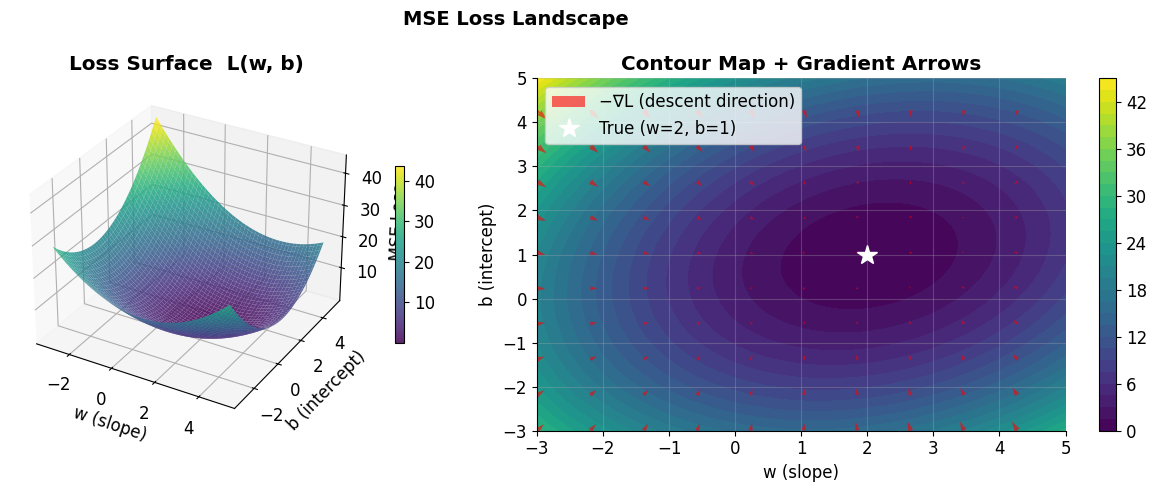

In [11]:
# Loss surface for a 2-parameter model
w_vals = np.linspace(-3, 5, 100)
b_vals = np.linspace(-3, 5, 100)
W, B   = np.meshgrid(w_vals, b_vals)

# True: y = 2x + 1  — fixed toy dataset
np.random.seed(42)
X_data = np.random.randn(30)
Y_data = 2 * X_data + 1 + 0.3 * np.random.randn(30)

def mse(w, b):
    preds = w * X_data + b
    return np.mean((Y_data - preds) ** 2)

Z = np.vectorize(mse)(W, B)

fig = plt.figure(figsize=(14, 5))

# 3D surface
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(W, B, Z, cmap='viridis', alpha=0.85)
ax1.set_xlabel('w (slope)')
ax1.set_ylabel('b (intercept)')
ax1.set_zlabel('MSE Loss')
ax1.set_title('Loss Surface  L(w, b)', fontweight='bold')
fig.colorbar(surf, ax=ax1, shrink=0.5)

# Contour with gradient arrows
ax2 = fig.add_subplot(122)
contour = ax2.contourf(W, B, Z, levels=30, cmap='viridis')
fig.colorbar(contour, ax=ax2)

# Sample gradient arrows
step = 10
dw = np.gradient(Z, axis=1)[::step, ::step]
db = np.gradient(Z, axis=0)[::step, ::step]
ax2.quiver(W[::step, ::step], B[::step, ::step],
           -dw, -db,
           color='red', alpha=0.6, scale=40, width=0.004,
           label='−∇L (descent direction)')
ax2.plot(2, 1, 'w*', markersize=15, label='True (w=2, b=1)')
ax2.set_xlabel('w (slope)')
ax2.set_ylabel('b (intercept)')
ax2.set_title('Contour Map + Gradient Arrows', fontweight='bold')
ax2.legend(loc='upper left')

plt.suptitle('MSE Loss Landscape', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 5️⃣ Chain Rule — The Heart of Backpropagation

The **chain rule** differentiates *compositions* of functions:

$$\frac{d}{dx}[f(g(x))] = f'(g(x)) \cdot g'(x)$$

Or in Leibniz notation (how backprop thinks):

$$\frac{dL}{dx} = \frac{dL}{dz} \cdot \frac{dz}{dx}$$

### 🧠 Neural Network Forward Pass

A single neuron computes:

$$z = wx + b \qquad a = \sigma(z) \qquad \mathcal{L} = (y - a)^2$$

### Backpropagation — Applying the Chain Rule

$$\frac{\partial \mathcal{L}}{\partial w} = \underbrace{\frac{\partial \mathcal{L}}{\partial a}}_{-2(y-a)} \cdot \underbrace{\frac{\partial a}{\partial z}}_{\sigma'(z)} \cdot \underbrace{\frac{\partial z}{\partial w}}_{x}$$

This chain unrolls through **every layer** of the network — that is backpropagation.


In [14]:
# ── Manual backprop through one neuron ──────────────────────────────────────

def sigmoid(z):      return 1 / (1 + np.exp(-z))
def d_sigmoid(z):    s = sigmoid(z); return s * (1 - s)

# Single training example
x_val, y_true = 2.0, 1.0
w, b          = 0.3, 0.1

# ── Forward pass ────────────────────────────────────────────
z = w * x_val + b
a = sigmoid(z)
L = (y_true - a) ** 2

print("=" * 46)
print("         FORWARD PASS")
print("=" * 46)
print(f"  z = wx + b       = {z:.4f}")
print(f"  a = σ(z)         = {a:.4f}")
print(f"  L = (y - a)²     = {L:.4f}")

# ── Backward pass (chain rule) ───────────────────────────────
dL_da = -2 * (y_true - a)
da_dz = d_sigmoid(z)
dz_dw = x_val
dz_db = 1.0

dL_dw = dL_da * da_dz * dz_dw
dL_db = dL_da * da_dz * dz_db

print("" + "=" * 46)
print("         BACKWARD PASS (Chain Rule)")
print("=" * 46)
print(f"  ∂L/∂a = -2(y-a)  = {dL_da:.4f}")
print(f"  ∂a/∂z = σ'(z)    = {da_dz:.4f}")
print(f"  ∂z/∂w = x        = {dz_dw:.4f}")
print(f"  ─────────────────────────────")
print(f"  ∂L/∂w = {dL_da:.3f} × {da_dz:.3f} × {dz_dw:.3f} = {dL_dw:.4f}")
print(f"  ∂L/∂b = {dL_da:.3f} × {da_dz:.3f} × {dz_db:.3f} = {dL_db:.4f}")

# ── Gradient update ──────────────────────────────────────────
lr = 0.5
print(f"  After gradient step (lr={lr}):")
print(f"  w ← {w:.3f} − {lr}×{dL_dw:.3f} = {w - lr*dL_dw:.4f}")
print(f"  b ← {b:.3f} − {lr}×{dL_db:.3f} = {b - lr*dL_db:.4f}")


         FORWARD PASS
  z = wx + b       = 0.7000
  a = σ(z)         = 0.6682
  L = (y - a)²     = 0.1101
         BACKWARD PASS (Chain Rule)
  ∂L/∂a = -2(y-a)  = -0.6636
  ∂a/∂z = σ'(z)    = 0.2217
  ∂z/∂w = x        = 2.0000
  ─────────────────────────────
  ∂L/∂w = -0.664 × 0.222 × 2.000 = -0.2943
  ∂L/∂b = -0.664 × 0.222 × 1.000 = -0.1471
  After gradient step (lr=0.5):
  w ← 0.300 − 0.5×-0.294 = 0.4471
  b ← 0.100 − 0.5×-0.147 = 0.1736


---
## 6️⃣ Gradient Descent — Training Any ML Model

The update rule that powers everything from linear regression to GPT:

$$\theta \leftarrow \theta - \eta \cdot \nabla_{\theta}\mathcal{L}$$

Where:
- $\theta$ — model parameters (weights & biases)
- $\eta$ — **learning rate** (how big a step we take)
- $\nabla_{\theta}\mathcal{L}$ — gradient of loss w.r.t. parameters

### Variants

| Variant | Description |
|---|---|
| **Batch GD** | Gradient over entire dataset |
| **Stochastic GD (SGD)** | Gradient over 1 sample — noisy but fast |
| **Mini-batch GD** | Gradient over small batch (32, 64…) — the standard |
| **Adam** | Adaptive learning rates per parameter — used in most modern models |

### Adam Update Rule

$$m_t = \beta_1 m_{t-1} + (1-\beta_1)\nabla\mathcal{L}$$
$$v_t = \beta_2 v_{t-1} + (1-\beta_2)(\nabla\mathcal{L})^2$$
$$\theta_t = \theta_{t-1} - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon}\hat{m}_t$$


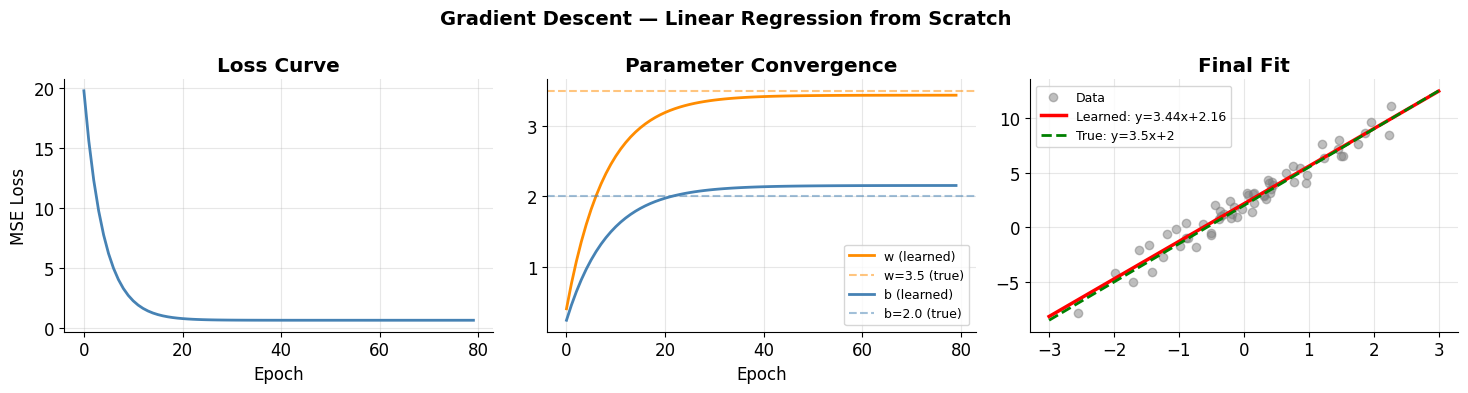

Final w = 3.4374  (true = 3.5)
Final b = 2.1554  (true = 2.0)
Final loss = 0.6709


In [15]:
# ── Gradient Descent: Linear Regression from scratch ────────────────────────

np.random.seed(0)
n     = 60
X_tr  = np.random.randn(n)
Y_tr  = 3.5 * X_tr + 2.0 + np.random.randn(n) * 0.8   # true: w=3.5, b=2.0

# Initialise parameters
w, b  = 0.0, 0.0
lr    = 0.05
epochs = 80

history = {'loss': [], 'w': [], 'b': []}

for epoch in range(epochs):
    y_hat  = w * X_tr + b
    loss   = np.mean((Y_tr - y_hat) ** 2)
    
    # Gradients
    dw = -2 * np.mean(X_tr * (Y_tr - y_hat))
    db = -2 * np.mean(Y_tr - y_hat)
    
    # Update
    w -= lr * dw
    b -= lr * db
    
    history['loss'].append(loss)
    history['w'].append(w)
    history['b'].append(b)

# ── Plot results ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss curve
axes[0].plot(history['loss'], color='steelblue', lw=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Loss Curve', fontweight='bold')

# Parameter convergence
axes[1].plot(history['w'], label='w (learned)', color='darkorange', lw=2)
axes[1].axhline(3.5, color='darkorange', linestyle='--', alpha=0.5, label='w=3.5 (true)')
axes[1].plot(history['b'], label='b (learned)', color='steelblue', lw=2)
axes[1].axhline(2.0, color='steelblue',   linestyle='--', alpha=0.5, label='b=2.0 (true)')
axes[1].set_xlabel('Epoch')
axes[1].set_title('Parameter Convergence', fontweight='bold')
axes[1].legend(fontsize=9)

# Final fit
axes[2].scatter(X_tr, Y_tr, alpha=0.5, label='Data', color='gray')
x_line = np.linspace(-3, 3, 100)
axes[2].plot(x_line, w * x_line + b, 'r-', lw=2.5,
             label=f'Learned: y={w:.2f}x+{b:.2f}')
axes[2].plot(x_line, 3.5 * x_line + 2, 'g--', lw=2,
             label='True: y=3.5x+2')
axes[2].set_title('Final Fit', fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle('Gradient Descent — Linear Regression from Scratch', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Final w = {w:.4f}  (true = 3.5)")
print(f"Final b = {b:.4f}  (true = 2.0)")
print(f"Final loss = {history['loss'][-1]:.4f}")


---
## 7️⃣ GenAI Deep Dive — Calculus Inside a Transformer

Every Generative AI model (GPT, Gemini, Claude) is built on the **Transformer** architecture.  
Calculus is invisible but present everywhere inside it.

### Softmax & Attention

The **attention score** for query $q$ and key $k$ is:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

The softmax converts raw scores to a **probability distribution** over tokens.  
Its gradient is needed during backpropagation to train the attention heads.

### Cross-Entropy Loss (Language Modeling)

Given true token $y$ and predicted probability $\hat{p}_y$:

$$\mathcal{L} = -\log(\hat{p}_y)$$

Its gradient w.r.t. logit $z_i$:

$$\frac{\partial \mathcal{L}}{\partial z_i} = \hat{p}_i - \mathbf{1}[i = y]$$

This elegantly clean gradient is why cross-entropy + softmax is the standard in GenAI.


In [18]:
# ── Softmax and Cross-Entropy — the loss of a language model ─────────────────

def softmax(z):
    e = np.exp(z - np.max(z))   # numerical stability
    return e / e.sum()

def cross_entropy(probs, true_idx):
    return -np.log(probs[true_idx] + 1e-12)

# Toy vocabulary: 6 tokens
vocab     = ['cat', 'sat', 'on', 'the', 'mat', 'dog']
true_word = 'mat'    # next token to predict
true_idx  = vocab.index(true_word)

# Raw logits from transformer output head (before softmax)
logits = np.array([1.2, 0.5, -0.3, 0.8, 2.1, -0.5])

probs = softmax(logits)
loss  = cross_entropy(probs, true_idx)

print("Token Predictions:")
print("-" * 38)
for tok, lg, pr in zip(vocab, logits, probs):
    bar   = '█' * int(pr * 30)
    star  = ' ← TRUE' if tok == true_word else ''
    print(f"  {tok:<6}  logit={lg:+.1f}  p={pr:.3f}  {bar}{star}")
print(f"Cross-Entropy Loss = {loss:.4f}")
print(f"Perplexity         = {np.exp(loss):.4f}")

# Gradient of loss w.r.t. logits
grad_logits = probs.copy()
grad_logits[true_idx] -= 1   # p_i − 1[i = y]

print("Gradients ∂L/∂z (push down wrong tokens, push up correct):")
for tok, g in zip(vocab, grad_logits):
    direction = '↑ increase' if g < 0 else '↓ decrease'
    print(f"  {tok:<6}  ∂L/∂z = {g:+.3f}  → {direction} logit")


Token Predictions:
--------------------------------------
  cat     logit=+1.2  p=0.199  █████
  sat     logit=+0.5  p=0.099  ██
  on      logit=-0.3  p=0.044  █
  the     logit=+0.8  p=0.133  ███
  mat     logit=+2.1  p=0.489  ██████████████ ← TRUE
  dog     logit=-0.5  p=0.036  █
Cross-Entropy Loss = 0.7159
Perplexity         = 2.0460
Gradients ∂L/∂z (push down wrong tokens, push up correct):
  cat     ∂L/∂z = +0.199  → ↓ decrease logit
  sat     ∂L/∂z = +0.099  → ↓ decrease logit
  on      ∂L/∂z = +0.044  → ↓ decrease logit
  the     ∂L/∂z = +0.133  → ↓ decrease logit
  mat     ∂L/∂z = -0.511  → ↑ increase logit
  dog     ∂L/∂z = +0.036  → ↓ decrease logit


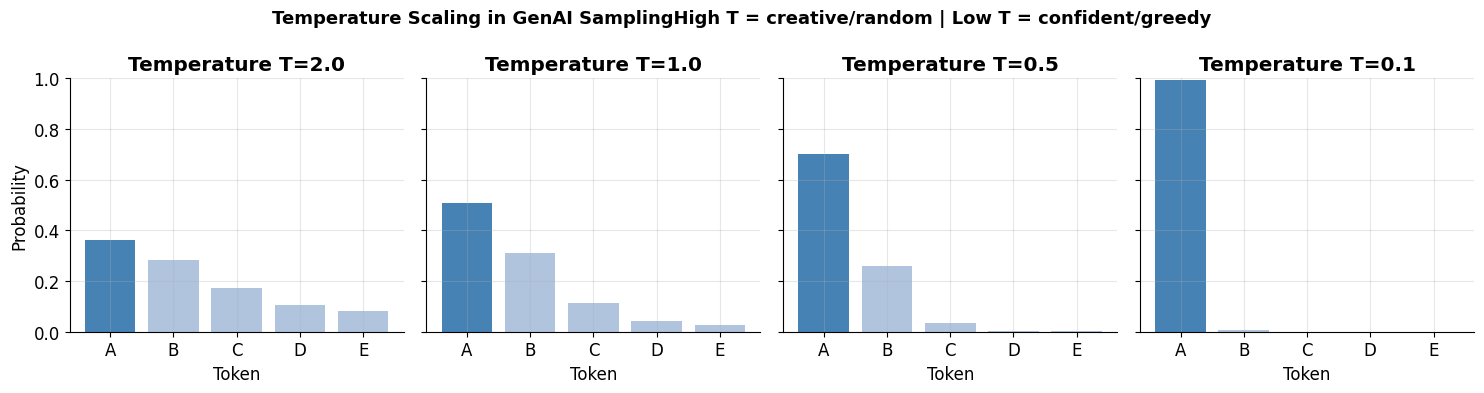

This is the 'temperature' parameter in ChatGPT, Claude, etc!
Mathematically: softmax(z / T) — calculus tells us why it sharpens/flattens.


In [20]:
# ── Visualise softmax sharpening (temperature scaling in GenAI) ──────────────

logits_base = np.array([2.0, 1.5, 0.5, -0.5, -1.0])
labels_base = ['A', 'B', 'C', 'D', 'E']
temps       = [2.0, 1.0, 0.5, 0.1]

fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharey=True)

for ax, T in zip(axes, temps):
    probs = softmax(logits_base / T)
    bars  = ax.bar(labels_base, probs,
                   color=['steelblue' if p == max(probs) else 'lightsteelblue' for p in probs])
    ax.set_title(f'Temperature T={T}', fontweight='bold')
    ax.set_ylim(0, 1)
    ax.set_xlabel('Token')
    if T == temps[0]:
        ax.set_ylabel('Probability')

plt.suptitle(
    'Temperature Scaling in GenAI Sampling'
    'High T = creative/random | Low T = confident/greedy',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

print("This is the 'temperature' parameter in ChatGPT, Claude, etc!")
print("Mathematically: softmax(z / T) — calculus tells us why it sharpens/flattens.")


---
## 8️⃣ Summary — Calculus → ML/GenAI Map

| Calculus Concept | ML/GenAI Use |
|---|---|
| **Limits** | Definition of derivative; numerical stability |
| **Derivatives** | Sensitivity of loss to any parameter |
| **Chain Rule** | Backpropagation through all layers |
| **Partial Derivatives** | Gradient w.r.t. each weight |
| **Gradient Descent** | Training: linear regression → GPT |
| **Softmax gradient** | Output layer of every LLM |
| **Cross-entropy** | Language model training objective |



In [21]:
# ── Quick reference: SymPy as your calculus calculator ───────────────────────

x, w, b, y = sp.symbols('x w b y', real=True)

# MSE loss for one sample
loss = (y - (w*x + b))**2

dL_dw = sp.diff(loss, w)
dL_db = sp.diff(loss, b)

print("MSE Loss:      L =", loss)
print("∂L/∂w        =", dL_dw)
print("∂L/∂b        =", dL_db)
print()

# Cross-entropy loss
p = sp.Symbol('p', positive=True)
ce = -sp.ln(p)
print("Cross-Entropy: L =", ce)
print("dL/dp         =", sp.diff(ce, p))


MSE Loss:      L = (-b - w*x + y)**2
∂L/∂w        = -2*x*(-b - w*x + y)
∂L/∂b        = 2*b + 2*w*x - 2*y

Cross-Entropy: L = -log(p)
dL/dp         = -1/p
